# Les grandes étapes de la partie Modélisation et évaluation de modèles

## Sommaire

1. Introduction 
2. Chargement des données
3. Préparation des données pour la modélisation 
4. Entraînement et évaluation des modèles de classification
5. Comparaison des modèles 
6. Choix du meilleur modèle
7. Conclusion de ce notebook 

## 1. Introduction 

### 1. Contexte 

Le jeu de données Titanic a fait l'objet d'une analyse exploratoire (EDA) puis d'un prétraitement complet comprenant le traitement des valeurs manquantes, le Feature Engineering et l'encodage des variables catégorielles. Les données sont désormais prêtes pour être utilisées par des algorithmes de Machine Learning.

L'objectif de ce notebook est de construire, entraîner et comparer plusieurs modèles de classification supervisée afin de prédire la survie des passagers du Titanic.

### 2. Objectifs

Les objectifs sont les suivants :

-   Charger les jeux de données préparés.
-   Préparer les données pour l'entraînement des modèles.
-   Entraîner plusieurs algorithmes de classification.
-   Évaluer les performances de chaque modèle à l'aide de métriques adaptées.
-   Comparer objectivement les modèles.
-   Identifier le modèle offrant les meilleures performances pour ce problème de classification.

### 3. Nature du problème

Le problème étudié est un problème de classification supervisée binaire.
Variable cible : Survived 

Deux classes sont possibles :

| Valeur | Signification               |
| ------ | --------------------------- |
| 0      | Le passager n'a pas survécu |
| 1      | Le passager a survécu       |


L'objectif des modèles sera donc de prédire correctement la classe de chaque passager.



## 2. Chargement des jeux de données 



### 1. Chargement des bibliothèques 

In [785]:
# Manipulation des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Préparation des données
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Métriques
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

Pourquoi ces bibliothèques ?


| Bibliothèque     | Utilité                                |
| ---------------- | -------------------------------------- |
| pandas           | Chargement et manipulation des données |
| numpy            | Calcul numérique                       |
| matplotlib       | Visualisation                          |
| seaborn          | Graphiques statistiques                |
| train_test_split | Séparation entraînement/test           |
| StandardScaler   | Standardisation des variables          |
| metrics          | Évaluation des modèles                 |


### 2. Chargement des jeux de données

In [786]:
# Chargement des jeux de données 
df_full = pd.read_csv("../data/processed/titanic_full_columns.csv")

df_less = pd.read_csv("../data/processed/titanic_less_columns.csv")

#### 1. Aperçu des jeux de données 

In [787]:
df_full.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin_known,FamilySize,IsAlone,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,0,22.0,1,0,7.2500,0,2,0,0,0,1,0,0,1,0,0
1,1,1,1,38.0,1,0,71.2833,1,2,0,1,0,0,0,0,0,1,0
2,1,3,1,26.0,0,0,7.9250,0,1,1,0,0,1,0,1,0,0,0
3,1,1,1,35.0,1,0,53.1000,1,2,0,0,0,1,0,0,0,1,0
4,0,3,0,35.0,0,0,8.0500,0,1,1,0,0,1,0,0,1,0,0


In [788]:
df_less.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin_known,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,0,22.0,1,0,7.2500,0,2,0,0,1,0,1,0,0
1,1,1,1,38.0,1,0,71.2833,1,2,0,0,0,0,0,1,0
2,1,3,1,26.0,0,0,7.9250,0,1,1,0,1,1,0,0,0
3,1,1,1,35.0,1,0,53.1000,1,2,0,0,1,0,0,1,0
4,0,3,0,35.0,0,0,8.0500,0,1,1,0,1,0,1,0,0


In [789]:
df_less.columns.tolist()


['Survived',
 'Pclass',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'Cabin_known',
 'FamilySize',
 'IsAlone',
 'Embarked_Q',
 'Embarked_S',
 'Title_Miss',
 'Title_Mr',
 'Title_Mrs',
 'Title_Rare']

#### 2. Dimensions 

In [790]:
print("Dataset complet :", df_full.shape)

print("Dataset réduit :", df_less.shape)

Dataset complet : (891, 18)
Dataset réduit : (891, 16)


#### 3. Vérification des valeurs manquantes  

In [791]:
print(df_full.isna().sum().sum())

print(df_less.isna().sum().sum())

0
0


Conclusion

Les deux jeux de données sont correctement chargés. Ils ne présentent plus de valeurs manquantes et sont prêts pour la phase de modélisation. Deux versions sont disponibles : une version avec toutes les catégories issues du One-Hot Encoding (df_full) et une version utilisant une catégorie de référence (df_less), adaptée aux modèles linéaires.

## 3. Préparation des données pour la modélisation 

Cette partie est essentielle. Elle consiste à séparer :
-   les variables explicatives ;
-   la variable cible.

Puis à constituer les ensembles d'entraînement et de test.

### 1. Séparation des variables explicatives et de la cible 

#### Dataset complet 

In [792]:
X_full = df_full.drop("Survived", axis=1)

y_full = df_full["Survived"]

#### Dataset réduit 

In [793]:
X_less = df_less.drop("Survived", axis=1)

y_less = df_less["Survived"]



#### Vérification

In [794]:
print(X_full.shape)

print(y_full.shape)

print(X_less.shape)

print(y_less.shape)

(891, 17)
(891,)
(891, 15)
(891,)


Conclusion

Les variables explicatives (X) ont été séparées de la variable cible (y). Cette étape est indispensable afin de fournir aux algorithmes les données d'entrée et les étiquettes à prédire.

### 2. Découpage des données en ensemble d'entraînement et de test 

***Pourquoi séparer les données?***

L'objectif d'un modèle de Machine Learning est de généraliser ses connaissances à de nouvelles observations.

Si l'on entraînait puis évaluait le modèle sur les mêmes données, celui-ci pourrait simplement mémoriser les exemples d'apprentissage. Les performances obtenues seraient alors trop optimistes et ne refléteraient pas son comportement sur de nouvelles données.

Pour éviter ce phénomène, appelé surapprentissage (overfitting), le dataset est divisé en deux ensembles :

-   Jeu d'entraînement (Training Set) : utilisé pour apprendre les relations entre les variables.
-   Jeu de test (Test Set) : utilisé uniquement pour mesurer les performances du modèle.

***Choix du ratio***


Le découpage retenu est :

-   80 % des observations pour l'entraînement ;
-   20 % des observations pour le test.

Ce ratio constitue un compromis largement utilisé en Machine Learning : il fournit suffisamment de données pour entraîner le modèle tout en conservant un nombre d'observations suffisant pour une évaluation fiable.

#### 1. Découpage du dataset réduit


In [795]:
from sklearn.model_selection import train_test_split

X_train_less, X_test_less, y_train_less, y_test_less = train_test_split(
    X_less,
    y_less,
    test_size=0.20,
    random_state=42,
    stratify=y_less
)

#### 2. Découpage du dataset complet


In [796]:
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full,
    y_full,
    test_size=0.20,
    random_state=42,
    stratify=y_full
)

#### 3. Découpage du dataset complet


In [797]:
print("===== Dataset LESS =====")

#print("X_train :", X_train_less.shape)
#print("X_test  :", X_test_less.shape)
#print("y_train :", y_train_less.shape)
#print("y_test  :", y_test_less.shape)

print(X_train_less.columns)

#print("===== Dataset FULL =====")

#print("X_train :", X_train_full.shape)
#print("X_test  :", X_test_full.shape)
#print("y_train :", y_train_full.shape)
#print("y_test  :", y_test_full.shape)

===== Dataset LESS =====
Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin_known',
       'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'Title_Miss',
       'Title_Mr', 'Title_Mrs', 'Title_Rare'],
      dtype='object')


***Pourquoi utiliser stratify ?***

La variable Survived n'est pas parfaitement équilibrée :

-   environ 62 % des passagers n'ont pas survécu ;
-   environ 38 % ont survécu.

Le paramètre : ***stratify = y***, garantit que cette répartition des classes dans le datasest originel  est conservée dans les jeux d'entraînement et de test.

Sans cette précaution, il serait possible d'obtenir un jeu de test contenant une proportion anormale de survivants ou de non-survivants, ce qui biaiserait l'évaluation des modèles.

***Pourquoi fixer random_state=42 ?***

Le découpage étant aléatoire, les observations sélectionnées pour les jeux d'entraînement et de test changeraient à chaque exécution.
Le paramètre : random_state=42; permet d'obtenir exactement le même découpage à chaque exécution, ce qui garantit la reproductibilité des expériences.


Conclusion

Les données ont été réparties entre un jeu d'entraînement (80 %) et un jeu de test (20 %). L'utilisation de stratify permet de conserver la distribution initiale de la variable cible tandis que random_state garantit la reproductibilité des résultats.

### 3. Standardisation des variables pour les modèles souffrant des échelles 

***Pourquoi standardiser ?***

Les variables numériques du dataset ne sont pas exprimées sur les mêmes échelles.

Par exemple :
-   Age varie entre 0 et 80 ans ;
-   Fare varie entre 0 et plus de 500.

Les modèles utilisant des calculs de distance ou des méthodes d'optimisation peuvent être fortement influencés par ces différences d'échelle.

La standardisation consiste à transformer les variables afin qu'elles soient centrées autour de 0 avec un écart-type égal à 1.

***Tous les modèles nécessitent-ils une standardisation ?***

| Modèle              | Standardisation nécessaire|
| ------------------- | --------------- |
| Logistic Regression | ✅ Oui           |
| KNN                 | ✅ Oui           |
| Decision Tree       | ❌ Non           |
| Random Forest       | ❌ Non           |


Les modèles basés sur les arbres prennent leurs décisions à partir de seuils sur les variables. Ils ne sont donc pas sensibles aux différences d'échelle.
En revanche, la Régression Logistique et KNN sont sensibles à la magnitude des variables et nécessitent une standardisation.

####  Standardisation du dataset réduit 

In [798]:
X_test_less.to_csv(
    "../data/processed/X_test_less_n03_avant_standardisation.csv",
    index=True
)

La standardisation est réalisée uniquement sur les données d'entraînement afin d'éviter toute fuite d'information (Data Leakage).

In [799]:
X_train_less

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin_known,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
692,3,0,28.0,0,0,56.4958,0,1,1,0,1,0,1,0,0
481,2,0,28.0,0,0,0.0000,0,1,1,0,1,0,1,0,0
527,1,0,28.0,0,0,221.7792,1,1,1,0,1,0,1,0,0
855,3,1,18.0,0,1,9.3500,0,2,0,0,1,0,0,1,0
801,2,1,31.0,1,1,26.2500,0,3,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,3,1,28.0,0,0,7.8792,0,1,1,1,0,1,0,0,0
258,1,1,35.0,0,0,512.3292,0,1,1,0,0,1,0,0,0
736,3,1,48.0,1,3,34.3750,0,5,0,0,1,0,0,1,0
462,1,0,47.0,0,0,38.5000,1,1,1,0,1,0,1,0,0


In [800]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_less_scaled = scaler.fit_transform(X_train_less)

X_test_less_scaled = scaler.transform(X_test_less)

from joblib import dump

dump(
    scaler,
    "../models/standard_scaler.pkl"
)

['../models/standard_scaler.pkl']

#### ***Pourquoi je n'ai standardisé que df_less ?***

Parce que, dans le plan que nous avons défini : 

-   **df_less** sera utilisé pour les modèles sensibles à l'échelle des variables :
    -   Régression Logistique
    -   KNN

-   **df_full** sera utilisé pour les modèles non sensibles à l'échelle :

    -   Decision Tree
    -   Random Forest

Dans ce cas, il est inutile de créer : X_train_full_scaled, X_test_full_scaled


In [801]:
# Vérification 

# Moyenne et ecart-type
print("Moyenne :", X_train_less_scaled.mean())
print("Ecart-type :", X_train_less_scaled.std())

# les dimensions 
print(X_train_less_scaled.shape)
print(X_test_less_scaled.shape)



Moyenne : 2.3950878733486524e-17
Ecart-type : 1.0
(712, 15)
(179, 15)


Cela confirme que les variables ont bien été centrées et réduites. La standardisation ne modifie jamais le nombre de lignes ni le nombre de variables.

### 4. Préparation des données pour les modèles non sensibles à l'échelle

Pour les modèles basés sur les arbres :
-   Decision Tree
-   Random Forest

on utilise directement :
-   X_train_full
-   X_test_full
-   y_train_full
-   y_test_full


Il n'y a aucune transformation supplémentaire.

Pourquoi ?
Parce que ces modèles utilisent des règles de séparation, et non des calculs de distance :

Exemple : Fare < 50 ?


### 5. Organisation finale des jeux de données 

#### 1. Pour Log.Reg. et KNN 


-   X_train_less_scaled
-   X_test_less_scaled

-   y_train_less
-   y_test_less

#### 2. Pour DecisionTree et RandomForest 

Données originales : 

-   X_train_full
-   X_test_full

-   y_train_full
-   y_test_full

#### 3. Pour Gradient Boosting Classifier

Données originales : 

-   X_train_full
-   X_test_full

-   y_train_full
-   y_test_full

#### 4. Pour XGBoost 

Données originales : 

-   X_train_full
-   X_test_full

-   y_train_full
-   y_test_full

#### 5. Pour SVM
Modèle basé sur les distances et les produits scalaires
Contrairement aux arbres, SVM est très sensible aux échelles.

Données  : 

-   X_train_less_scaled
-   X_test_less_scaled

-   y_train_less
-   y_test_less

#### 6. ***Tableau récap***

| Modèle              | Famille                | Dataset   | Standardisation |
| ------------------- | ---------------------- | --------- | --------------- |
| Logistic Regression | Linéaire               | `df_less` | ✅ Oui           |
| KNN                 | Distance               | `df_less` | ✅ Oui           |
| SVM                 | Hyperplan / distance   | `df_less` | ✅ Oui           |
| Decision Tree       | Arbre                  | `df_full` | ❌ Non           |
| Random Forest       | Bagging arbres         | `df_full` | ❌ Non           |
| Gradient Boosting   | Boosting arbres        | `df_full` | ❌ Non           |
| XGBoost             | Boosting arbres avancé | `df_full` | ❌ Non           |


#### 7. Conclusion :

Les données ont été préparées en fonction des contraintes propres aux différents algorithmes de classification étudiés. Les modèles sensibles aux différences d'échelle, comme la Régression Logistique, KNN et SVM, utiliseront les données issues du dataset réduit après standardisation. Les modèles basés sur des arbres de décision, tels que Decision Tree, Random Forest, Gradient Boosting et XGBoost, utiliseront les données issues du dataset complet sans standardisation. Les jeux de données nécessaires à l'entraînement des différents modèles sont donc disponibles.


## 4. Entrainement et évaluation des modèles de classification 

Modèles retenus :

-   Logistic Regression
-   K-Nearest Neighbors (KNN)
-   Support Vector Machine (SVM)
-   Decision Tree Classifier
-   Random Forest Classifier
-   Gradient Boosting Classifier
-   XGBoost Classifier

### 0. Préparation de la collecte des résultats

Avant de commencer les modèles, on crée une structure permettant d'enregistrer automatiquement les performances.



In [802]:
results = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1-score": [],
    "ROC-AUC": []
}

On importe les métriques : 

In [803]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

Voici la Fonction d'évaluation commune :

In [804]:
def evaluate_model(model_name, y_test, y_pred, y_prob):

    results["Model"].append(model_name)

    results["Accuracy"].append(
        accuracy_score(y_test, y_pred)
    )

    results["Precision"].append(
        precision_score(y_test, y_pred)
    )

    results["Recall"].append(
        recall_score(y_test, y_pred)
    )

    results["F1-score"].append(
        f1_score(y_test, y_pred)
    )

    results["ROC-AUC"].append(
        roc_auc_score(y_test, y_prob)
    )

Cette fonction évite de recopier le même code pour chaque modèle.

### 1. Régréssion Logistique 

***Présentation***

La Régression Logistique est un modèle statistique utilisé pour résoudre des problèmes de classification binaire.
Elle calcule la probabilité qu'une observation appartienne à une classe.

Dans notre cas :
-   classe 0 : non survivant ;
-   classe 1 : survivant.

Elle constitue un excellent modèle de référence (baseline) car elle est :
-   simple ;
-   rapide ;
-   interprétable.

***Données utilisées***

La Régression Logistique étant sensible à l'échelle des variables, elle utilise :
-   X_train_less_scaled
-   X_test_less_scaled

-   y_train_less
-   y_test_less



#### Entrainement 



In [805]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    random_state=42
)

lr.fit(
    X_train_less_scaled,
    y_train_less
)


LogisticRegression(random_state=42)

#### Prédictions 



In [806]:
y_pred_lr = lr.predict(
    X_test_less_scaled
)

y_prob_lr = lr.predict_proba(
    X_test_less_scaled
)[:,1]

#### Evaluation 



In [807]:
evaluate_model(
    "Logistic Regression",
    y_test_less,
    y_pred_lr,
    y_prob_lr
)

#### Matrice de confusion

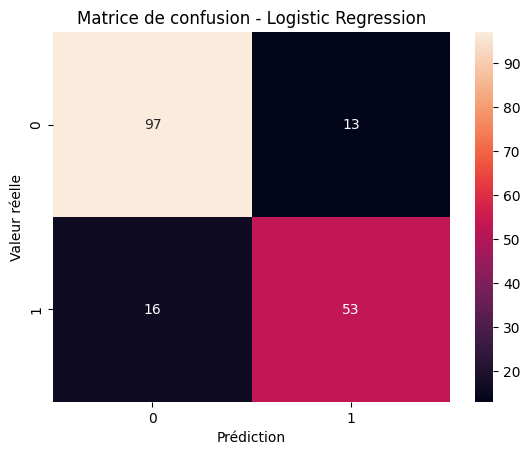

In [808]:
cm = confusion_matrix(
    y_test_less,
    y_pred_lr
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")
plt.title("Matrice de confusion - Logistic Regression")
plt.show()

**Conclusion**

La Régression Logistique fournit une première estimation de la capacité prédictive du modèle. Elle permet également d'identifier les variables ayant le plus d'influence grâce aux coefficients associés aux variables.


### 2. K-Nearest Neighbors (KNN) 

***Présentation***

KNN est un algorithme basé sur la proximité entre observations.
Pour prédire la survie d'un passager :
-   il recherche les passagers les plus similaires ;
-   il attribue la classe majoritaire parmi ces voisins.

***Données utilisées***

Le KNN étant sensible à l'échelle des variables, il utilise :
-   X_train_less_scaled
-   X_test_less_scaled

-   y_train_less
-   y_test_less



#### Entrainement 



In [809]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train_less_scaled,
    y_train_less
)

KNeighborsClassifier()

#### Prédictions 



In [810]:
y_pred_knn = knn.predict(
    X_test_less_scaled
)

y_prob_knn = knn.predict_proba(
    X_test_less_scaled
)[:,1]

#### Evaluation 



In [811]:
evaluate_model(
    "KNN",
    y_test_less,
    y_pred_knn,
    y_prob_knn
)

**Conclusion**

KNN permet de comparer une approche basée sur la similarité entre individus. Ses performances dépendent fortement du choix de la distance et du paramètre n_neighbors.

### 3. Support Vector machine (SVM) 

***Présentation***

SVM cherche à trouver une frontière optimale séparant les différentes classes.
Son objectif est de maximiser la marge entre les classes.

***Données utilisées***

Le KNN étant sensible à l'échelle des variables, il utilise :
-   X_train_less_scaled
-   X_test_less_scaled

-   y_train_less
-   y_test_less



#### Entrainement 



In [812]:
from sklearn.svm import SVC

svm = SVC(
    probability=True,
    random_state=42
)

svm.fit(
    X_train_less_scaled,
    y_train_less
)

SVC(probability=True, random_state=42)

#### Prédictions 



In [813]:
y_pred_svm = svm.predict(
    X_test_less_scaled
)

y_prob_svm = svm.predict_proba(
    X_test_less_scaled
)[:,1]

#### Evaluation 



In [814]:
evaluate_model(
    "SVM",
    y_test_less,
    y_pred_svm,
    y_prob_svm
)

**Conclusion**

SVM permet d'évaluer un modèle plus complexe basé sur la séparation optimale des classes. Il peut être performant mais nécessite un réglage précis de ses hyperparamètres.

### 4. Decision Tree Classifier

***Présentation***

L'arbre de décision construit une succession de règles permettant de séparer les observations.

***Données utilisées***

Le Decision Tree n'étant pas sensible à l'échelle des variables, il utilise :
-   X_train_full
-   X_test_full

-   y_train_full
-   y_test_full



#### Entrainement 



In [815]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train_full,
    y_train_full
)

DecisionTreeClassifier(random_state=42)

#### Prédictions 



In [816]:
y_pred_dt = dt.predict(
    X_test_full
)

y_prob_dt = dt.predict_proba(
    X_test_full
)[:,1]

#### Evaluation 



In [817]:
evaluate_model(
    "Decision Tree",
    y_test_full,
    y_pred_dt,
    y_prob_dt
)

**Conclusion**

L'arbre est facilement interprétable mais présente un risque important de surapprentissage lorsqu'il devient trop complexe.

### 5. Random Forest

***Présentation***

Random Forest combine plusieurs arbres de décision. Chaque arbre apprend une partie du problème puis les prédictions sont agrégées.
Avantages :
-   réduit le surapprentissage ;
-   améliore la robustesse ;
-   fournit l'importance des variables.

***Données utilisées***

Le Random Forest n'étant pas sensible à l'échelle des variables, il utilise :
-   X_train_full
-   X_test_full

-   y_train_full
-   y_test_full



#### Entrainement 



In [818]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train_full,
    y_train_full
)

RandomForestClassifier(random_state=42)

#### Prédictions 



In [819]:
y_pred_rf = rf.predict(
    X_test_full
)

y_prob_rf = rf.predict_proba(
    X_test_full
)[:,1]

#### Evaluation 



In [820]:
evaluate_model(
    "Random Forest",
    y_test_full,
    y_pred_rf,
    y_prob_rf
)

**Conclusion**

Random Forest est généralement plus performant qu'un arbre seul grâce à la combinaison de plusieurs modèles.

### 6. Gradient Boosting Classifier

***Présentation***

Gradient Boosting construit plusieurs arbres successifs.
Chaque nouvel arbre corrige les erreurs du précédent.

***Données utilisées***

Le Gradient Boosting n'étant pas sensible à l'échelle des variables, il utilise :
-   X_train_full
-   X_test_full

-   y_train_full
-   y_test_full



#### Entrainement 



In [821]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(
    random_state=42
)

gbc.fit(
    X_train_full,
    y_train_full
)

GradientBoostingClassifier(random_state=42)

#### Prédictions 



In [822]:
y_pred_gbc = gbc.predict(
    X_test_full
)

y_prob_gbc = gbc.predict_proba(
    X_test_full
)[:,1]

#### Evaluation 



In [823]:
evaluate_model(
    "Gradient Boosting",
    y_test_full,
    y_pred_gbc,
    y_prob_gbc
)

**Conclusion**

Gradient Boosting permet souvent d'obtenir de très bonnes performances sur des données tabulaires comme Titanic.

### 7. XGBoost

***Présentation***

XGBoost est une implémentation optimisée du Gradient Boosting.
Il est très utilisé dans les compétitions Kaggle et les projets industriels.

***Données utilisées***

Le Gradient Boosting n'étant pas sensible à l'échelle des variables, il utilise :
-   X_train_full
-   X_test_full

-   y_train_full
-   y_test_full



#### Installation si nécessaire 



In [824]:
pip install xgboost

You should consider upgrading via the '/Users/othmanbenmoussa/Desktop/Titanic_Classification/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


#### Entrainement 



In [825]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(
    X_train_full,
    y_train_full
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

#### Prédictions 



In [826]:
y_pred_xgb = xgb.predict(
    X_test_full
)

y_prob_xgb = xgb.predict_proba(
    X_test_full
)[:,1]

#### Evaluation 



In [827]:
evaluate_model(
    "XGBoost",
    y_test_full,
    y_pred_xgb,
    y_prob_xgb
)

**Conclusion**

XGBoost constitue un modèle avancé permettant souvent d'obtenir d'excellentes performances, mais son interprétation est plus complexe que celle des modèles plus simples.

#### **Conclusion de la partie 4**

À l'issue de cette étape, sept modèles de classification appartenant à différentes familles algorithmiques ont été entraînés et évalués.
Les modèles testés couvrent :
-   les approches linéaires ;
-   les méthodes basées sur la distance ;
-   les modèles à marge ;
-   les arbres de décision ;
-   les méthodes d'ensemble (ensemble learning) avec Random Forest, Gradient Boosting et XGBoost.

Les performances obtenues seront maintenant regroupées dans la partie suivante afin de comparer objectivement les modèles et sélectionner celui offrant le meilleur compromis entre performance et robustesse.

## 5. Comparaison des modèles 

### 5.1 Création du tableau de comparaison des performances

**Objectif**

Après l'entraînement des différents modèles, leurs performances sont comparées à travers plusieurs métriques.

Les métriques utilisées sont :
-   Accuracy : proportion globale de bonnes prédictions ;
-   Precision : capacité du modèle à identifier correctement les survivants parmi les survivants prédits ;
-   Recall : capacité du modèle à retrouver les véritables survivants ;
-   F1-score : compromis entre précision et rappel ;
-   ROC-AUC : capacité globale du modèle à distinguer les deux classes.


***Création du DataFrame de résultats***

In [828]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.837989,0.803030,0.768116,0.785185,0.873650
1,KNN,0.798883,0.739130,0.739130,0.739130,0.843149
2,SVM,0.826816,0.796875,0.739130,0.766917,0.847563
3,Decision Tree,0.782123,0.714286,0.724638,0.719424,0.770553
4,Random Forest,0.793296,0.728571,0.739130,0.733813,0.829974
5,Gradient Boosting,0.826816,0.816667,0.710145,0.759690,0.842292
6,XGBoost,0.804469,0.742857,0.753623,0.748201,0.833333


### 5.2 Crlassement des modèles selon les  performances

Afin d'obtenir une vision globale, on classe les modèles selon le F1-score.

Pourquoi le F1-score ?
Dans notre problème Titanic, les classes ne sont pas parfaitement équilibrées :
-   0 : non-survivant
-   1 : survivant

L'accuracy seule peut être trompeuse.

Le F1-score permet de prendre en compte simultanément :
-   la précision ;
-   le rappel.


In [829]:
results_df.sort_values(
    by="F1-score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.837989,0.803030,0.768116,0.785185,0.873650
2,SVM,0.826816,0.796875,0.739130,0.766917,0.847563
5,Gradient Boosting,0.826816,0.816667,0.710145,0.759690,0.842292
6,XGBoost,0.804469,0.742857,0.753623,0.748201,0.833333
1,KNN,0.798883,0.739130,0.739130,0.739130,0.843149
4,Random Forest,0.793296,0.728571,0.739130,0.733813,0.829974
3,Decision Tree,0.782123,0.714286,0.724638,0.719424,0.770553


### 5.2 Comparasion graphique des modèles

Les graphiques permettent une lecture plus intuitive des différences entre modèles.


***Comparaison de l'accuracy***

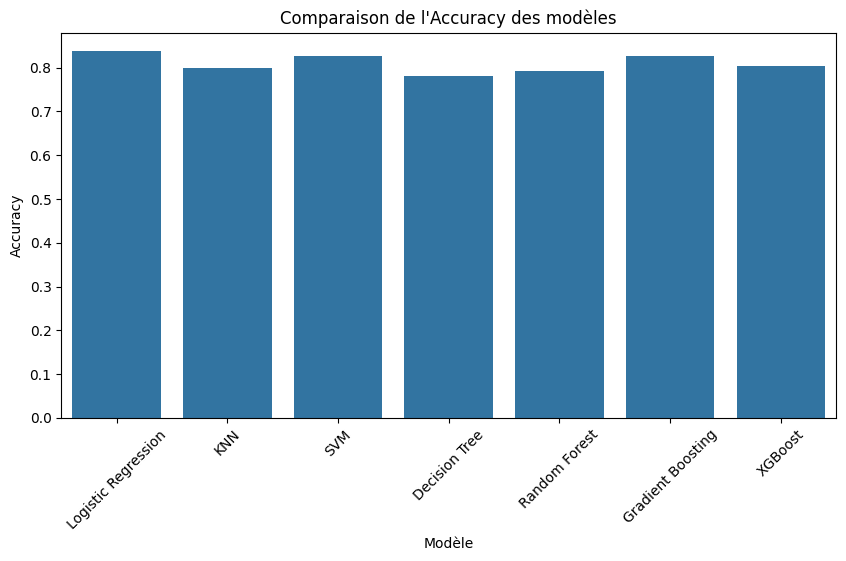

In [830]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.xticks(rotation=45)
plt.title("Comparaison de l'Accuracy des modèles")
plt.ylabel("Accuracy")
plt.xlabel("Modèle")

plt.show()

Interprétation attendue : 

Ce graphique montre la proportion globale de prédictions correctes.
Un modèle avec une accuracy élevée réalise globalement peu d'erreurs.

Cependant, cette métrique ne suffit pas seule car elle ne distingue pas :
-   les survivants correctement détectés ;
-   les survivants mal classés.

***Comparaison du Recall***

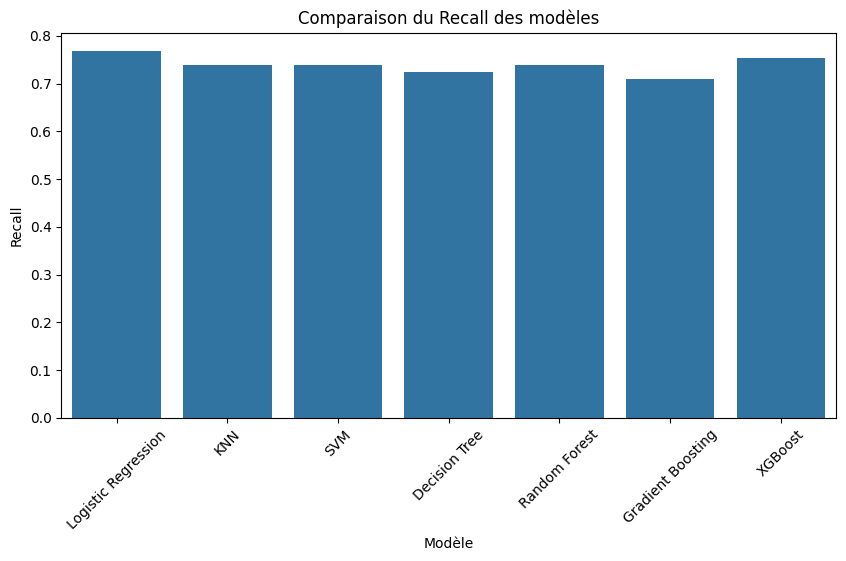

In [831]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Recall"
)

plt.xticks(rotation=45)
plt.title("Comparaison du Recall des modèles")
plt.ylabel("Recall")
plt.xlabel("Modèle")

plt.show()

Interprétation

Le recall mesure la capacité du modèle à détecter les survivants.
Un recall élevé signifie :
-   Le modèle retrouve une grande partie des passagers ayant effectivement survécu.
-   Dans un contexte Titanic, cette métrique est importante car manquer un survivant correspond à une erreur critique.

***Comparaison du F1-Score***

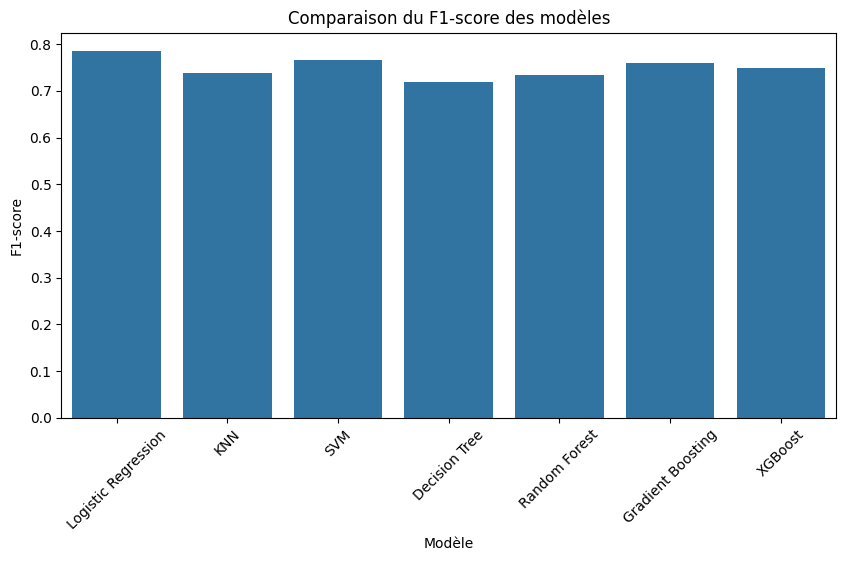

In [832]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1-score"
)

plt.xticks(rotation=45)

plt.title(
    "Comparaison du F1-score des modèles"
)

plt.ylabel("F1-score")

plt.xlabel("Modèle")

plt.show()

Interprétation

Le F1-score représente souvent la métrique principale de comparaison.
Le meilleur modèle est celui qui obtient le F1-score le plus élevé.
Il offre le meilleur compromis entre :
-   éviter les faux survivants ;
-   détecter correctement les survivants.

***Comparaison du ROC-AUC***

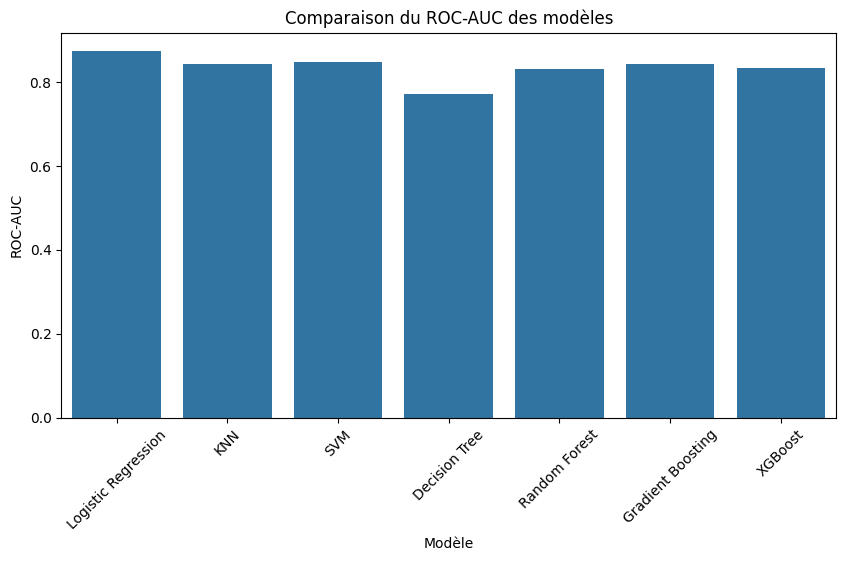

In [833]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="ROC-AUC"
)

plt.xticks(rotation=45)

plt.title(
    "Comparaison du ROC-AUC des modèles"
)

plt.ylabel("ROC-AUC")

plt.xlabel("Modèle")

plt.show()

Interprétation

Le ROC-AUC mesure la capacité du modèle à séparer :
-   les survivants ;
-   les non-survivants.

Contrairement à l'accuracy, cette métrique dépend moins du seuil de décision.
Plus le score est proche de 1 : meilleure est la séparation des classes.

#### 5.4 Analyse globale des performances

Pour faciliter la comparaison, on peut visualiser toutes les métriques.


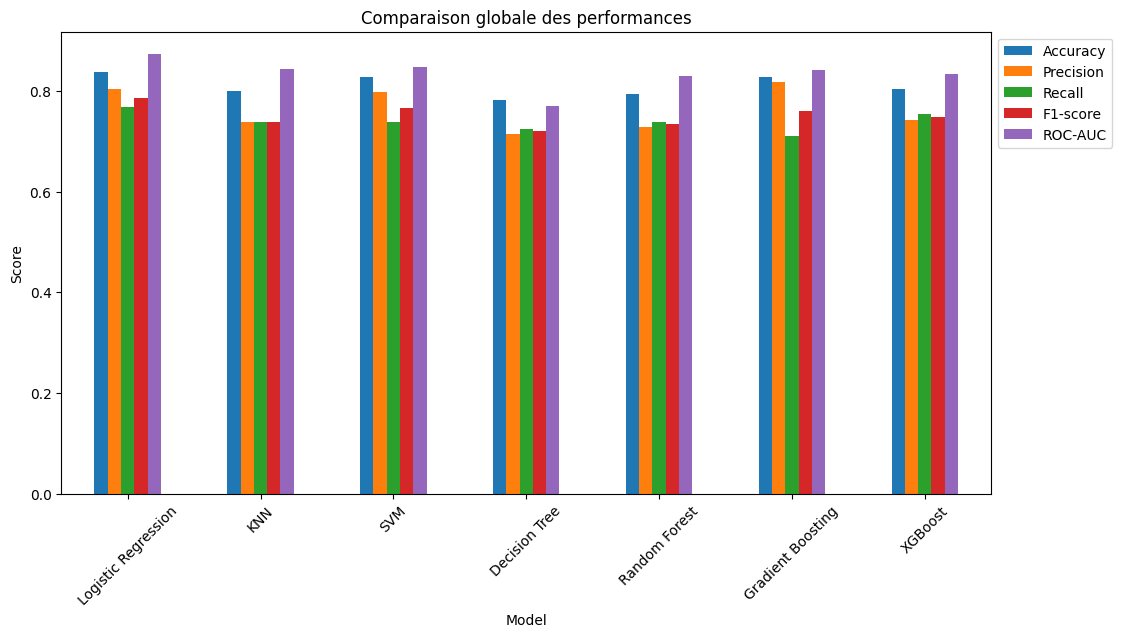

In [834]:
results_df.set_index("Model").plot(
    kind="bar",
    figsize=(12,6)
)

plt.title(
    "Comparaison globale des performances"
)

plt.ylabel("Score")

plt.xticks(rotation=45)

plt.legend(
    bbox_to_anchor=(1,1)
)

plt.show()

#### 5.5 Analyse et interprétation des résultats

L'analyse comparative des modèles montre que la Régression Logistique obtient les meilleures performances globales avec une accuracy de 83,8 %, un F1-score de 78,5 % et un ROC-AUC de 87,4 %. Malgré la complexité supérieure des modèles d'ensemble comme Random Forest, Gradient Boosting et XGBoost, ceux-ci n'apportent pas d'amélioration significative sur ce jeu de données.
Cette performance s'explique par la nature du problème Titanic et par la qualité du Feature Engineering réalisé. Les variables sélectionnées présentent des relations relativement structurées avec la survie, ce qui permet à un modèle linéaire d'obtenir une excellente capacité de généralisation.
La Régression Logistique est donc retenue comme meilleur modèle pour cette première phase de modélisation.



In [835]:
results_df.sort_values(
    by="F1-score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.837989,0.803030,0.768116,0.785185,0.873650
2,SVM,0.826816,0.796875,0.739130,0.766917,0.847563
5,Gradient Boosting,0.826816,0.816667,0.710145,0.759690,0.842292
6,XGBoost,0.804469,0.742857,0.753623,0.748201,0.833333
1,KNN,0.798883,0.739130,0.739130,0.739130,0.843149
4,Random Forest,0.793296,0.728571,0.739130,0.733813,0.829974
3,Decision Tree,0.782123,0.714286,0.724638,0.719424,0.770553


### 6. Choix du meilleur modèle 

#### 1. Objectif 

À l'issue de l'entraînement et de la comparaison des différents algorithmes, il est nécessaire de sélectionner le modèle qui sera retenu pour la suite du projet. Ce choix ne repose pas uniquement sur l'accuracy, mais sur une analyse globale des performances, de la robustesse et de l'interprétabilité du modèle.

#### 2. Synthèse des performances

Tu peux rappeler le classement obtenu :

| Rang | Modèle              |  Accuracy |  F1-score |   ROC-AUC |
| ---- | ------------------- | --------: | --------: | --------: |
| 🥇   | Logistic Regression | **0.838** | **0.785** | **0.874** |
| 🥈   | SVM                 |     0.827 |     0.767 |     0.847 |
| 🥉   | Gradient Boosting   |     0.827 |     0.760 |     0.842 |
| 4    | XGBoost             |     0.804 |     0.748 |     0.833 |
| 5    | KNN                 |     0.799 |     0.739 |     0.844 |
| 6    | Random Forest       |     0.793 |     0.734 |     0.830 |
| 7    | Decision Tree       |     0.782 |     0.719 |     0.771 |




#### 3. Justification du choix 

Tu peux rédiger quelque chose comme :

Parmi les sept modèles évalués, la Régression Logistique obtient les meilleures performances sur l'ensemble des métriques étudiées. Elle présente la meilleure accuracy (83,8 %), le meilleur F1-score (78,5 %) ainsi que le meilleur score ROC-AUC (87,4 %). Ces résultats montrent qu'elle est capable de distinguer efficacement les survivants des non-survivants tout en conservant un bon équilibre entre précision et rappel.

Au-delà des performances, la Régression Logistique présente également l'avantage d'être simple à entraîner, rapide à exécuter et facilement interprétable. Les coefficients du modèle permettent notamment de mesurer l'influence des variables explicatives sur la probabilité de survie.

#### 4. Perspectives d'évolutions

Même si un modèle est retenu, il est toujours possible de l'améliorer.

Les résultats obtenus correspondent aux paramètres par défaut des différents algorithmes. Une amélioration des performances pourrait être obtenue grâce à une optimisation des hyperparamètres (GridSearchCV ou RandomizedSearchCV), à une validation croisée plus approfondie ou encore à la création de nouvelles variables pertinentes lors du Feature Engineering.

## 7. Conclusion du notebook 

Ce notebook avait pour objectif d'entraîner, d'évaluer et de comparer plusieurs modèles de classification afin de prédire la survie des passagers du Titanic. Sept algorithmes représentatifs de différentes familles de modèles ont été étudiés. Les performances ont été évaluées à l'aide de plusieurs métriques complémentaires, permettant une comparaison objective des modèles.

Les résultats montrent que la Régression Logistique est le modèle offrant le meilleur compromis entre performance, robustesse et simplicité d'interprétation. Elle est donc retenue comme modèle de référence pour cette étude.

Ce travail constitue une première étape de modélisation. Des travaux complémentaires pourraient porter sur l'optimisation des hyperparamètres, l'utilisation de techniques de validation croisée plus poussées, ainsi que l'interprétation détaillée des variables influençant la prédiction à l'aide des coefficients du modèle ou de méthodes d'explicabilité comme SHAP.




In [836]:
X_train_less_scaled = pd.DataFrame(
    X_train_less_scaled,
    columns=X_train_less.columns,
    index=X_train_less.index
)


X_test_less_scaled = pd.DataFrame(
    X_test_less_scaled,
    columns=X_test_less.columns,
    index=X_test_less.index
)

X_train_full = pd.DataFrame(
    X_train_full,
    columns=X_train_full.columns,
    index=X_train_full.index
)


X_test_full = pd.DataFrame(
    X_test_full,
    columns=X_test_full.columns,
    index=X_test_full.index
)



In [837]:
import os

path = "../data/processed/"

os.makedirs(path, exist_ok=True)

# Sauvegarde du dataset réduit standardisé
## Variables explicatives
X_train_less_scaled.to_csv(
    path + "X_train_less_scaled.csv",
    index=False
)

X_test_less_scaled.to_csv(
    path + "X_test_less_scaled.csv",
    index=False
)


## Variable cible
y_train_less.to_csv(
    path + "y_train_less.csv",
    index=False
)

y_test_less.to_csv(
    path + "y_test_less.csv",
    index=False
)

# Sauvegarde du dataset complet 

# Variables explicatives

X_train_full.to_csv(
    path + "X_train_full.csv",
    index=False
)

X_test_full.to_csv(
    path + "X_test_full.csv",
    index=False
)


# Variable cible

y_train_full.to_csv(
    path + "y_train_full.csv",
    index=False
)

y_test_full.to_csv(
    path + "y_test_full.csv",
    index=False
)



In [838]:
X_test_less_scaled.to_csv(
    "../data/processed/X_test_less_scaled_n_03.csv", index=False)